# Filter & Clean

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from rank_bm25 import BM25Okapi

In [150]:
df = pd.read_csv('./perenual_data.csv', delimiter = ',')

In [151]:
df.head()

,Unnamed: 0,id,common_name,scientific_name,other_name,family,hybrid,authority,subspecies,cultivar,...,default_image.license_name,default_image.license_url,default_image.original_url,default_image.regular_url,default_image.medium_url,default_image.small_url,default_image.thumbnail,pruning_count.amount,pruning_count.interval,default_image
0,0,1,European Silver Fir,['Abies alba'],['Common Silver Fir'],Pinaceae,NaN,NaN,NaN,NaN,...,Attribution-ShareAlike 3.0 Unported (CC BY-SA ...,https://creativecommons.org/licenses/by-sa/3.0...,https://perenual.com/storage/species_image/1_a...,https://perenual.com/storage/species_image/1_a...,https://perenual.com/storage/species_image/1_a...,https://perenual.com/storage/species_image/1_a...,https://perenual.com/storage/species_image/1_a...,NaN,NaN,NaN
1,1,2,Pyramidalis Silver Fir,"[""Abies alba 'Pyramidalis'""]",[],Pinaceae,NaN,NaN,NaN,Pyramidalis,...,Attribution-ShareAlike License,https://creativecommons.org/licenses/by-sa/2.0/,https://perenual.com/storage/species_image/2_a...,https://perenual.com/storage/species_image/2_a...,https://perenual.com/storage/species_image/2_a...,https://perenual.com/storage/species_image/2_a...,https://perenual.com/storage/species_image/2_a...,NaN,NaN,NaN
2,2,3,White Fir,['Abies concolor'],"['Silver Fir', 'Concolor Fir', 'Colorado Fir']",Pinaceae,NaN,NaN,NaN,NaN,...,Attribution-ShareAlike License,https://creativecommons.org/licenses/by-sa/2.0/,https://perenual.com/storage/species_image/3_a...,https://perenual.com/storage/species_image/3_a...,https://perenual.com/storage/species_image/3_a...,https://perenual.com/storage/species_image/3_a...,https://perenual.com/storage/species_image/3_a...,NaN,NaN,NaN
3,3,4,Candicans White Fir,"[""Abies concolor 'Candicans'""]","['Silver Fir', 'Concolor Fir', 'Colorado Fir']",Pinaceae,NaN,NaN,NaN,Candicans,...,Attribution-ShareAlike License,https://creativecommons.org/licenses/by-sa/2.0/,https://perenual.com/storage/species_image/4_a...,https://perenual.com/storage/species_image/4_a...,https://perenual.com/storage/species_image/4_a...,https://perenual.com/storage/species_image/4_a...,https://perenual.com/storage/species_image/4_a...,2.0,yearly,NaN
4,4,5,Fraser Fir,['Abies fraseri'],['Southern Fir'],Pinaceae,NaN,NaN,NaN,NaN,...,Attribution License,https://creativecommons.org/licenses/by/2.0/,https://perenual.com/storage/species_image/5_a...,https://perenual.com/storage/species_image/5_a...,https://perenual.com/storage/species_image/5_a...,https://perenual.com/storage/species_image/5_a...,https://perenual.com/storage/species_image/5_a...,NaN,NaN,NaN


In [152]:
df.columns

Index(['Unnamed: 0', 'id', 'common_name', 'scientific_name', 'other_name',
       'family', 'hybrid', 'authority', 'subspecies', 'cultivar', 'variety',
       'species_epithet', 'genus', 'origin', 'type', 'dimensions', 'cycle',
       'attracts', 'propagation', 'watering', 'plant_anatomy', 'sunlight',
       'pruning_month', 'pruning_count', 'seeds', 'maintenance', 'care_guides',
       'soil', 'growth_rate', 'drought_tolerant', 'salt_tolerant', 'thorny',
       'invasive', 'tropical', 'indoor', 'care_level', 'pest_susceptibility',
       'flowers', 'flowering_season', 'cones', 'fruits', 'edible_fruit',
       'harvest_season', 'leaf', 'edible_leaf', 'cuisine', 'medicinal',
       'poisonous_to_humans', 'poisonous_to_pets', 'description',
       'other_images', 'xWateringQuality', 'xWateringPeriod',
       'xWateringAvgVolumeRequirement', 'xWateringDepthRequirement',
       'xWateringBasedTemperature', 'xWateringPhLevel', 'xSunlightDuration',
       'xTemperatureTolence', 'xPlantSpacin

In [153]:
print("Total rows:", df.shape[0])

unique_common = df['common_name'].nunique()
print("Unique common names:", unique_common)

unique_scientific = df['scientific_name'].nunique()
print("Unique scientific names:", unique_scientific)

missing_desc = df['description'].isna().sum()
print("Missing descriptions:", missing_desc)

missing_sci = df['scientific_name'].isna().sum()
print("Missing scientific names:", missing_sci)

duplicates = df[df['scientific_name'].duplicated(keep=False)]
print("Duplicate scientific name rows:", duplicates.shape[0])


Total rows: 3000
Unique common names: 1548
Unique scientific names: 3000
Missing descriptions: 10
Missing scientific names: 0
Duplicate scientific name rows: 0


- There are total of 3000 unique scietific names, but we will use common names with total of 1548 to match better human's understanding of plants.
- There are some missing data in the dataset but overal we will keep all rows to not miss any of plants.

# 1. Define columns to keep

In [154]:
# Label column
LABEL_COL = "common_name"

# Main descriptive text columns (B)
TEXT_COLS_MAIN = [
    "scientific_name",
    "description",
    "plant_anatomy",
    
]

TEXT_COLS_PROPS = [
    "care_level",
    "maintenance",
    "growth_rate",
    "sunlight",
    "soil",
    "leaf",
    "flowers",
    "fruits",
    "watering",
    "cycle",
    "origin",
    "dimensions",
    "attracts",
    "drought_tolerant",
    "salt_tolerant",
    "thorny",
    "edible_fruit",
    "harvest_season",
    "medicinal",
    "poisonous_to_humans",
    "poisonous_to_pets",
]



TEXT_COLS_ALL = TEXT_COLS_MAIN + TEXT_COLS_PROPS


# All columns we want to keep in the cleaned dataframe
COLUMNS_TO_KEEP = [LABEL_COL]  + TEXT_COLS_ALL



# 2. Make a working copy & subset columns

In [155]:

print("Original shape:", df.shape)

# Keep only the columns we care about (ignore missing ones safely)
existing_cols = [c for c in COLUMNS_TO_KEEP if c in df.columns]
df_clean = df[existing_cols].copy()
print("After subsetting to relevant columns:", df_clean.shape)

Original shape: (3000, 77)
After subsetting to relevant columns: (3000, 25)


# 4. Build unified 'text' column from all text-like fields

In [156]:
import pandas as pd
import ast

# ======================================================
# 1. Define columns by type
# ======================================================

FREE_TEXT_COLS = [
    "description",
    "plant_anatomy",
]

CATEGORICAL_COLS = [
    "sunlight",
    "soil",
    "watering",
    "cycle",
    "origin",
    "care_level",
    "maintenance",
    "growth_rate",
    "dimensions",
    "attracts",
    "harvest_season",
]

BOOL_COLS = [
    "leaf",
    "flowers",
    "fruits",
    "drought_tolerant",
    "salt_tolerant",
    "thorny",
    "edible_fruit",
    "medicinal",
    "poisonous_to_humans",
    "poisonous_to_pets",
]

# Filter to only columns that actually exist
FREE_TEXT_COLS = [c for c in FREE_TEXT_COLS if c in df_clean.columns]
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in df_clean.columns]
BOOL_COLS       = [c for c in BOOL_COLS if c in df_clean.columns]


# ======================================================
# 2. Human-readable prefixes for categorical fields
# ======================================================

CAT_PREFIX = {
    "common_name": "Common name:",
    "sunlight": "Sunlight:",
    "soil": "Soil:",
    "watering": "Watering:",
    "cycle": "Growth cycle:",
    "origin": "Origin:",
    "care_level": "Care level:",
    "maintenance": "Maintenance:",
    "growth_rate": "Growth rate:",
    "dimensions": "Dimensions:",
    "attracts": "Attracts:",
    "harvest_season": "Harvest season:",
}


# ======================================================
# 3. Phrases for boolean traits (TRUE and FALSE)
# ======================================================

BOOL_PHRASES_TRUE = {
    "leaf": "has leaves.",
    "flowers": "has flowers.",
    "fruits": "has fruits.",
    "drought_tolerant": "drought tolerant.",
    "salt_tolerant": "salt tolerant.",
    "thorny": "thorny.",
    "edible_fruit": "has edible fruit.",
    "medicinal": "has medicinal uses.",
    "poisonous_to_humans": "poisonous to humans.",
    "poisonous_to_pets": "poisonous to pets.",
}

BOOL_PHRASES_FALSE = {
    "leaf": "has no leaves.",
    "flowers": "has no flowers.",
    "fruits": "has no fruits.",
    "drought_tolerant": "not drought tolerant.",
    "salt_tolerant": "not salt tolerant.",
    "thorny": "not thorny.",
    "edible_fruit": "no edible fruit.",
    "medicinal": "no known medicinal uses.",
    "poisonous_to_humans": "not poisonous to humans.",
    "poisonous_to_pets": "not poisonous to pets.",
}


# ======================================================
# 4. Helpers: truthy / falsy detection
# ======================================================

def is_truthy(x):
    x_str = str(x).strip().lower()
    return x_str in ["true", "1", "yes", "y", "t"]

def is_falsy(x):
    x_str = str(x).strip().lower()
    return x_str in ["false", "0", "no", "n", "f"]


# ======================================================
# 5. Helper: clean list-like or quoted categorical strings
# ======================================================

def clean_categorical_value(val):
    """
    Turn things like:
      "['Austria', 'Germany']" -> "Austria, Germany"
      "'full sun'"            -> "full sun"
    into nice plain text.
    """
    if pd.isna(val):
        return ""
    s = str(val).strip()
    if s == "" or s == "[]":
        return ""

    # Try to parse list/dict literals like "['a', 'b']"
    try:
        obj = ast.literal_eval(s)
    except Exception:
        obj = None

    if isinstance(obj, list):
        return ", ".join(str(x) for x in obj)
    # For dicts we'll handle specific ones like dimensions separately
    if isinstance(obj, dict):
        return s

    # Fallback: remove outer quotes and strip list artifacts
    if (s.startswith("'") and s.endswith("'")) or (s.startswith('"') and s.endswith('"')):
        s = s[1:-1]

    # Clean up common patterns from list-like strings
    s = s.replace("', '", ", ").replace('", "', ", ")
    s = s.replace("['", "").replace("']", "").replace('["', "").replace('"]', "")

    return s.strip()


# ======================================================
# 6. Helper: Convert plant_anatomy into readable text
# ======================================================

def format_plant_anatomy(val):
    if pd.isna(val):
        return ""
    s = str(val).strip()
    if s == "" or s == "[]":
        return ""
    try:
        data = ast.literal_eval(s) if isinstance(val, str) else val
    except Exception:
        return s  # if parsing fails, just return raw

    parts = []
    if isinstance(data, list):
        for item in data:
            part = item.get("part", "")
            colors = item.get("color", [])
            if isinstance(colors, list):
                colors = ", ".join(colors)
            if part and colors:
                parts.append(f"{part}: {colors}")
            elif part:
                parts.append(part)
    return ". ".join(parts)


# ======================================================
# 7. Helper: format dimensions dict into English
# ======================================================

def format_dimensions(val):
    """
    Example raw:
      {'type': 'Height', 'min_value': 60, 'max_value': 60, 'unit': 'feet'}
    Output:
      "Height about 60 feet"
    or:
      "Height between 10 and 20 feet"
    """
    if pd.isna(val):
        return ""
    s = str(val).strip()
    if s == "" or s == "[]":
        return ""
    try:
        obj = ast.literal_eval(s) if isinstance(val, str) else val
    except Exception:
        return clean_categorical_value(val)  # fallback

    if isinstance(obj, dict):
        dim_type = obj.get("type", "") or "Size"
        dim_type = str(dim_type).capitalize()
        min_v = obj.get("min_value", None)
        max_v = obj.get("max_value", None)
        unit = str(obj.get("unit", "")).strip()

        if min_v is not None and max_v is not None:
            if min_v == max_v:
                return f"{dim_type} about {max_v} {unit}".strip()
            else:
                return f"{dim_type} between {min_v} and {max_v} {unit}".strip()
        elif max_v is not None:
            return f"{dim_type} up to {max_v} {unit}".strip()
        elif min_v is not None:
            return f"{dim_type} at least {min_v} {unit}".strip()

    # If we can't parse nicely, fall back to generic cleanup
    return clean_categorical_value(val)


# ======================================================
# 8. Main builder: create text for each row
# ======================================================

def build_semantic_text(row):
    parts = []

    # A) Free-text columns
    for col in FREE_TEXT_COLS:
        val = row.get(col, None)
        if col == "plant_anatomy":
            pa = format_plant_anatomy(val)
            if pa:
                parts.append(pa)
            continue

        if pd.notna(val):
            s = str(val).strip()
            if s and s != "[]":
                parts.append(s)

    # B) Categorical columns
    for col in CATEGORICAL_COLS:
        val = row.get(col, None)
        if pd.notna(val):
            if col == "dimensions":
                s = format_dimensions(val)
            else:
                s = clean_categorical_value(val)
            if s:
                label = CAT_PREFIX.get(col, f"{col}:")
                parts.append(f"{label} {s}")

    # C) Boolean columns → phrase for True and False
    for col in BOOL_COLS:
        val = row.get(col, None)
        if pd.isna(val):
            continue
        if is_truthy(val):
            phrase = BOOL_PHRASES_TRUE.get(col)
        elif is_falsy(val):
            phrase = BOOL_PHRASES_FALSE.get(col)
        else:
            phrase = None
        if phrase:
            parts.append(phrase)

    # Join everything into one long text
    text = " ".join(parts)
    text = text.replace("  ", " ").replace("[]", "").strip()
    return text


# ======================================================
# 9. Apply to df_clean
# ======================================================

df_clean["text"] = df_clean.apply(build_semantic_text, axis=1)
df_clean = df_clean[df_clean["text"].str.strip() != ""]

print("Example merged text:\n")
print(df_clean["text"].iloc[0][:5000])


Example merged text:

European Silver Fir (Abies alba) is an amazing coniferous species native to mountainous regions of central Europe and the Balkans. It is an evergreen tree with a narrow, pyramidal shape and long, soft needles. Its bark is scaly grey-brown and its branches are highly ornamental due to its conical-shaped silver-tinged needles. It is pruned for use as an ornamental evergreen hedging and screening plant, and is also popular for use as a Christmas tree. Young trees grow quickly and have strong, flexible branches which makes them perfect for use as windbreaks. The European Silver Fir is an impressive species, making it ideal for gardens and public spaces. Sunlight: full sun Watering: Frequent Growth cycle: Perennial Origin: Austria, Germany, Switzerland, France, Italy, Slovenia, Croatia, Bosnia and Herzegovina, Serbia, Montenegro, Albania, Bulgaria, Romania, Ukraine, Poland, Czech Republic, Slovakia, Hungary Care level: Medium Growth rate: High Dimensions: {'type': 'Hei

In [157]:
df_clean.columns

Index(['common_name', 'scientific_name', 'description', 'plant_anatomy',
       'care_level', 'maintenance', 'growth_rate', 'sunlight', 'soil', 'leaf',
       'flowers', 'fruits', 'watering', 'cycle', 'origin', 'dimensions',
       'attracts', 'drought_tolerant', 'salt_tolerant', 'thorny',
       'edible_fruit', 'harvest_season', 'medicinal', 'poisonous_to_humans',
       'poisonous_to_pets', 'text'],
      dtype='object')

# Compute missing counts

In [158]:
# some cells have "[]" which is basically a missing info but it is not NaN so I first convert them to NaN 
for col in df_clean.columns:
    if df_clean[col].astype(str).str.strip().eq("[]").any():
        print(f"Column '{col}' contains empty list placeholders []")

cols_to_fix = [
    "plant_anatomy", "care_guides", "sunlight", "soil", "leaf", 
    "flowers", "fruits", "watering", "origin"
]

for col in cols_to_fix:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(
            lambda x: np.nan if str(x).strip() == "[]" else x
        )



Column 'plant_anatomy' contains empty list placeholders []
Column 'soil' contains empty list placeholders []
Column 'origin' contains empty list placeholders []
Column 'attracts' contains empty list placeholders []


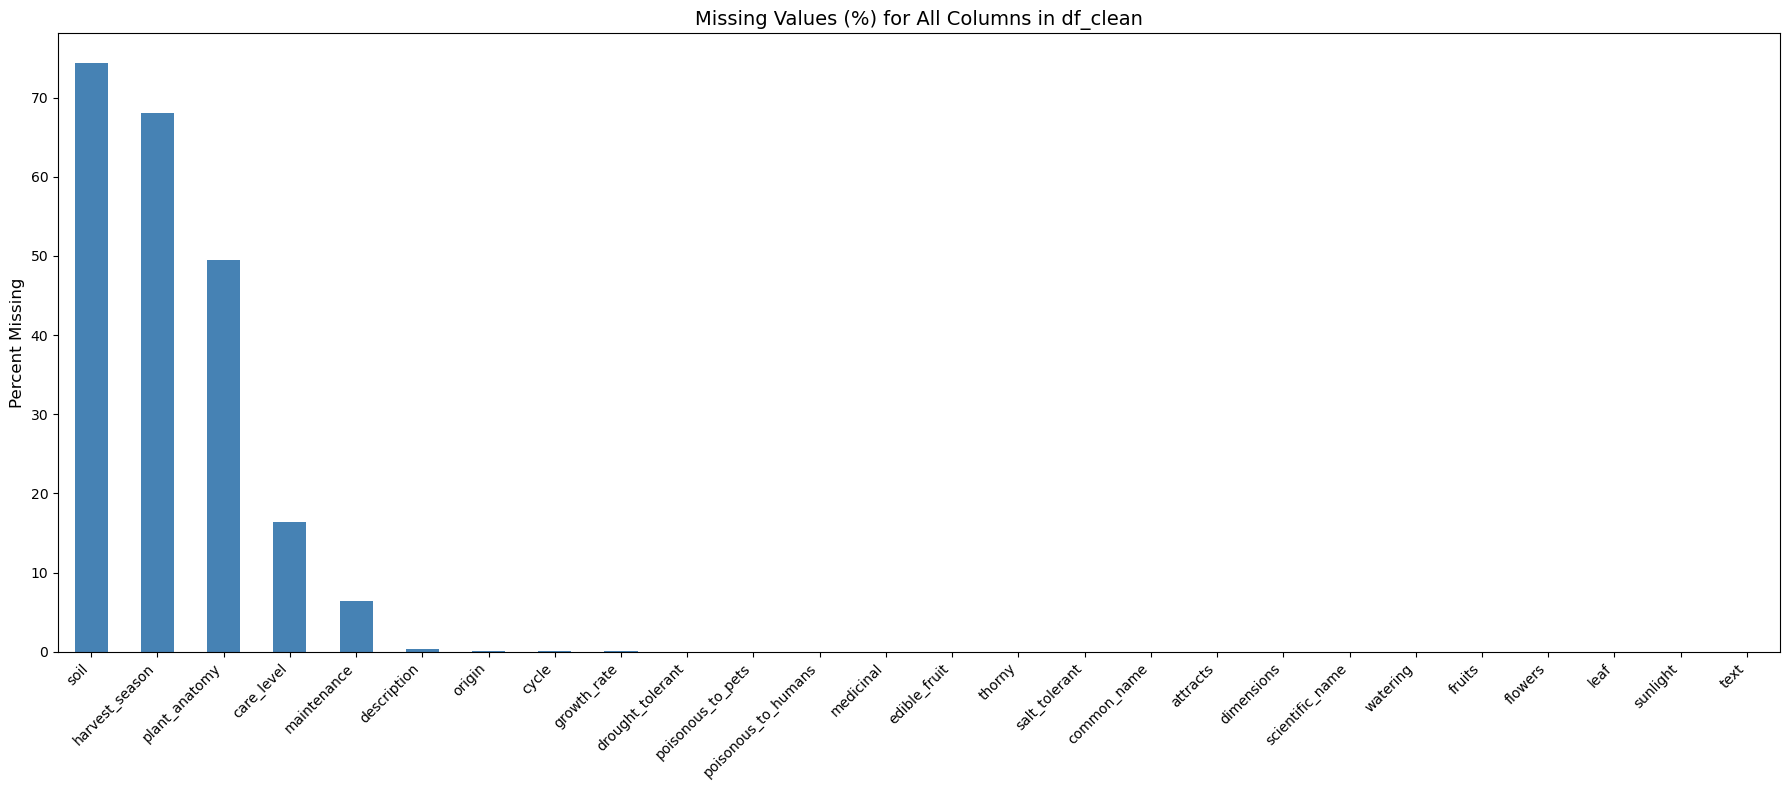

In [159]:
import matplotlib.pyplot as plt

# Calculate missing percentages
missing_percent = df_clean.isna().mean() * 100

# Sort from most missing → least
missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(18, 8))
ax = missing_percent.plot(kind="bar", color="steelblue")

plt.title("Missing Values (%) for All Columns in df_clean", fontsize=14)
plt.ylabel("Percent Missing", fontsize=12)

ax.set_xticks(range(len(missing_percent)))
ax.set_xticklabels(missing_percent.index, rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()


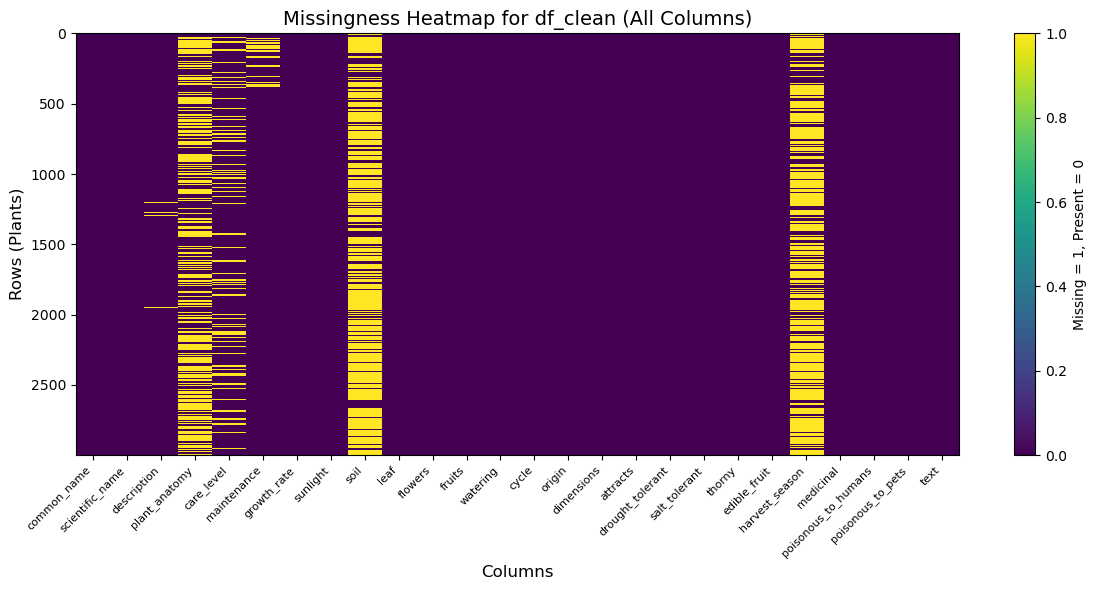

In [160]:
import numpy as np
import matplotlib.pyplot as plt

# Boolean missing matrix
missing_matrix = df_clean.isna().values

plt.figure(figsize=(12, 6))
plt.imshow(missing_matrix, aspect='auto', interpolation='nearest')

plt.colorbar(label="Missing = 1, Present = 0")

plt.title("Missingness Heatmap for df_clean (All Columns)", fontsize=14)
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Rows (Plants)", fontsize=12)

# Use column names on x-axis
plt.xticks(
    ticks=np.arange(len(df_clean.columns)),
    labels=df_clean.columns,
    rotation=45,
    ha='right',
    fontsize=8
)

plt.tight_layout()
plt.show()


Columns being plotted: ['common_name', 'scientific_name', 'plant_anatomy', 'care_level', 'maintenance', 'growth_rate', 'sunlight', 'soil', 'leaf', 'flowers', 'fruits', 'watering', 'cycle', 'origin', 'dimensions', 'attracts', 'drought_tolerant', 'salt_tolerant', 'thorny', 'edible_fruit', 'harvest_season', 'medicinal', 'poisonous_to_humans', 'poisonous_to_pets']


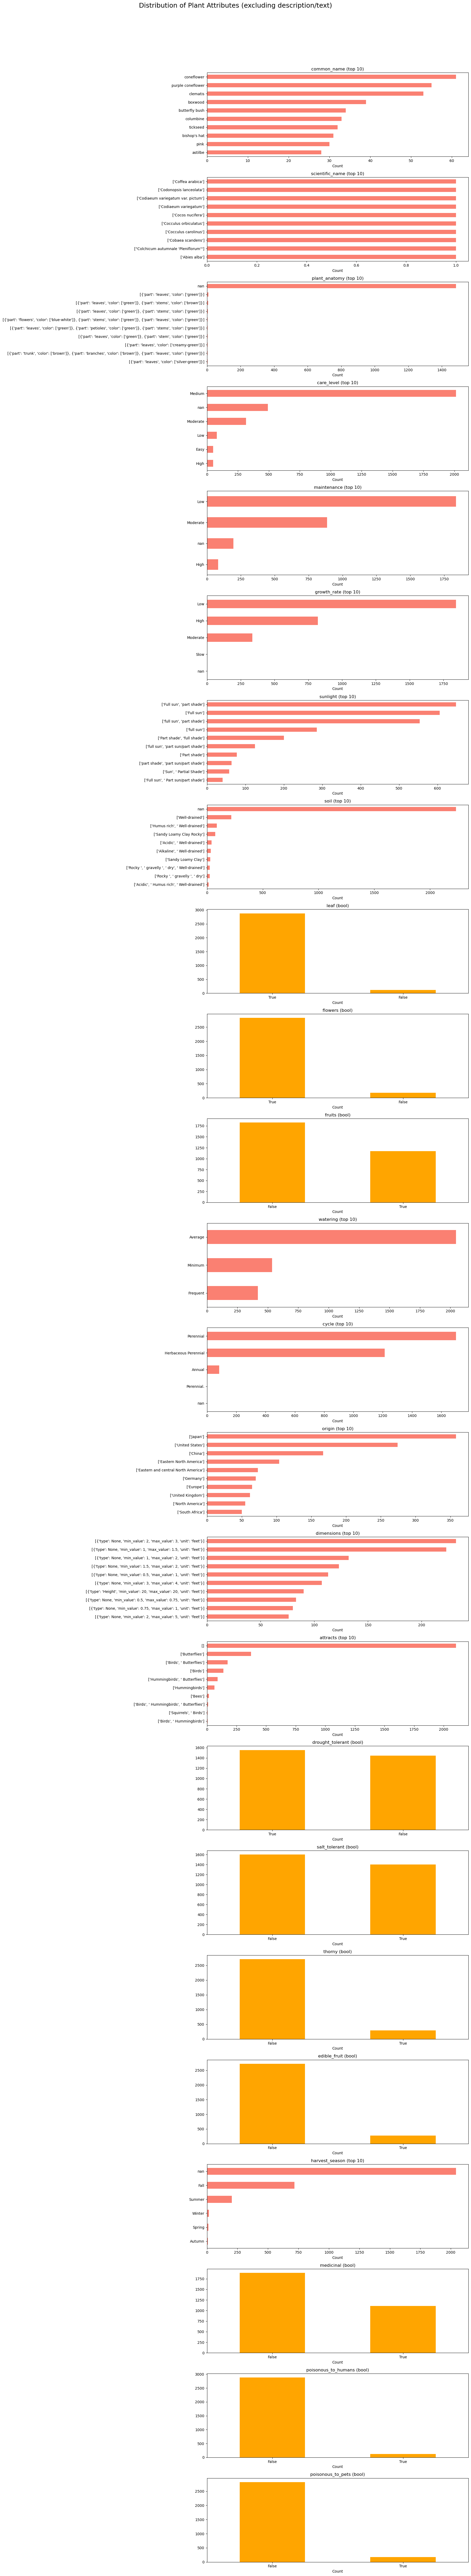

In [161]:

df = df_clean.copy()

# Columns to exclude (you can add more if needed)
EXCLUDE_COLS = ["description", "text"]

# Filter columns
cols = [c for c in df.columns if c not in EXCLUDE_COLS]
print("Columns being plotted:", cols)

n = len(cols)
ncols = 1
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(18, nrows * 4))

for i, col in enumerate(cols, start=1):
    plt.subplot(nrows, ncols, i)
    
    series = df[col]
    series_no_na = series.dropna()

    # Case: all missing
    if series_no_na.shape[0] == 0:
        plt.text(0.5, 0.5, "All missing", ha="center")
        plt.title(col)
        continue

    # 1) Boolean → treat as categorical
    if pd.api.types.is_bool_dtype(series):
        vc = series_no_na.value_counts()
        vc.plot(kind="bar", color="orange")
        plt.title(f"{col} (bool)")
        plt.xticks(rotation=0)
        plt.xlabel("Count")

    # 2) Numeric → histogram
    elif pd.api.types.is_numeric_dtype(series):
        if series_no_na.nunique() > 1:
            plt.hist(series_no_na, bins=20, color="skyblue")
            plt.title(f"{col} (numeric)")
        else:
            plt.text(0.5, 0.5, "No variation", ha="center")
            plt.title(col)

    # 3) Categorical / text → Top-10 most frequent
    else:
        series_clean = (
            series.astype(str)
                  .str.strip()
                  .replace("", "UNKNOWN")
        )
        vc = series_clean.value_counts().head(10).sort_values(ascending=True)
        vc.plot(kind="barh", color="salmon")
        plt.title(f"{col} (top 10)")
        plt.xlabel("Count")

    plt.tight_layout()

plt.suptitle("Distribution of Plant Attributes (excluding description/text)", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()


In [162]:
# making sure that there is no "[]" in the text column
df_clean["text"] = df_clean["text"].str.replace(r"\[\]", " ", regex=True)



In [163]:
df_clean["text"] = (
    df_clean["text"]
        .str.replace("True", "", regex=False)
        .str.replace("False", "", regex=False)
        .str.replace("Yes", "", regex=False)
        .str.replace("No", "", regex=False)
)


In [164]:
df_clean["text"] = (
    df_clean["text"]
        .str.replace(r"\[|\]|\{|\}|\(|\)", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)   # collapse spaces
        .str.strip()
)


In [165]:
df_clean["text"] = df_clean["text"].astype(str)


In [166]:
# Main CSV export
output_path = "perenualData_clean.csv"
df_clean.to_csv(output_path, index=False)

# TF-IDF Model using Text column

In [172]:
import ast
import numpy as np

def normalize_common_name(x):
    
    s = str(x).strip()

    # Try to parse list-like strings
    try:
        obj = ast.literal_eval(s)
        if isinstance(obj, list) and len(obj) > 0:
            s = str(obj[0]).strip()
    except Exception:
        pass

    # Strip outer quotes
    if (s.startswith("'") and s.endswith("'")) or (s.startswith('"') and s.endswith('"')):
        s = s[1:-1]

    return s.strip().lower()


In [173]:
# 1. Load training and test datasets
df_clean = pd.read_csv("transformed_wiki_descriptions_with_perenual_data_text.csv")
df_test  = pd.read_csv("transformed_wiki_descriptions_with_perenual_data_text.csv")

# 2. Build training documents and labels (SCIENTIFIC NAMES)
train_docs = df_clean["perenual_data_text"].fillna("").astype(str).values
train_labels_raw = df_clean["name"].astype(str).values
train_labels = np.array([normalize_common_name(x) for x in train_labels_raw])

# 3. Build test queries and true SCIENTIFIC labels
test_queries = df_test["user_description"].fillna("").astype(str).values
true_labels_raw = df_test["name"].astype(str).values
true_labels = np.array([normalize_common_name(x) for x in true_labels_raw])

# Optional sanity check
print("Unique train sci names:", len(set(train_labels)))
print("Unique test sci names:", len(set(true_labels)))
print("Overlap:", len(set(train_labels) & set(true_labels)))


Unique train sci names: 1157
Unique test sci names: 1157
Overlap: 1157


In [169]:
 # ----------------------------------------------------
# 2. TF-IDF model
# ----------------------------------------------------
tfidf = TfidfVectorizer(
    max_features=None,
    ngram_range=(1, 2),
    lowercase=True,
)

X_train = tfidf.fit_transform(train_docs)
X_test  = tfidf.transform(test_queries)

print("TF-IDF shapes:", X_train.shape, X_test.shape)

sim_tfidf = cosine_similarity(X_test, X_train)   # (n_test, n_train)

def hits_at_k(sim_matrix, true_labels, train_labels, k=10):
    # returns top-k indices
    topk_idx = np.argpartition(-sim_matrix, k-1, axis=1)[:, :k]
    topk_names = train_labels[topk_idx]

    return np.mean([
        true_labels[i] in topk_names[i]
        for i in range(len(true_labels))
    ])

# ------------------------------
# TF-IDF Top-1
# ------------------------------
best_idx_tfidf = sim_tfidf.argmax(axis=1)
pred_tfidf = train_labels[best_idx_tfidf]
tfidf_top1 = (pred_tfidf == true_labels).mean()

# ------------------------------
# TF-IDF Top-5
# ------------------------------
tfidf_top05 = hits_at_k(sim_tfidf, true_labels, train_labels, k=5)

# ------------------------------
# TF-IDF Top-10
# ------------------------------
tfidf_top10 = hits_at_k(sim_tfidf, true_labels, train_labels, k=10)

print(f"\nTF-IDF Top-1 Accuracy model2:  {tfidf_top1:.3f}")
print(f"TF-IDF Top-5 Accuracy model2: {tfidf_top05:.3f}")
print(f"TF-IDF Top-10 Accuracy model2: {tfidf_top10:.3f}")


TF-IDF shapes: (1174, 51414) (1174, 51414)

TF-IDF Top-1 Accuracy model2:  0.033
TF-IDF Top-5 Accuracy model2: 0.085
TF-IDF Top-10 Accuracy model2: 0.129


In [174]:
print(sim_tfidf[0])

[0.01570742 0.06259084 0.02147409 ... 0.04399588 0.0392844  0.04147808]


# TF-IDF Model using generated description

In [170]:
# 1. Load training and test datasets
df_clean = pd.read_csv("transformed_wiki_descriptions_with_generated_descriptions.csv")
df_test  = pd.read_csv("transformed_wiki_descriptions_with_generated_descriptions.csv")

# 2. Build training documents and labels (SCIENTIFIC NAMES)
train_docs = df_clean["generated_description"].fillna("").astype(str).values
train_labels_raw = df_clean["name"].astype(str).values
train_labels = np.array([normalize_common_name(x) for x in train_labels_raw])

# 3. Build test queries and true SCIENTIFIC labels
test_queries = df_test["user_description"].fillna("").astype(str).values
true_labels_raw = df_test["name"].astype(str).values
true_labels = np.array([normalize_common_name(x) for x in true_labels_raw])

# Optional sanity check
print("Unique train sci names:", len(set(train_labels)))
print("Unique test sci names:", len(set(true_labels)))
print("Overlap:", len(set(train_labels) & set(true_labels)))


Unique train sci names: 1157
Unique test sci names: 1157
Overlap: 1157


In [171]:
 # ----------------------------------------------------
# 2. TF-IDF model
# ----------------------------------------------------
tfidf = TfidfVectorizer(
    max_features=None,
    ngram_range=(1, 2),
    lowercase=True,
)

X_train = tfidf.fit_transform(train_docs)
X_test  = tfidf.transform(test_queries)

print("TF-IDF shapes:", X_train.shape, X_test.shape)

sim_tfidf = cosine_similarity(X_test, X_train)   # (n_test, n_train)

def hits_at_k(sim_matrix, true_labels, train_labels, k=10):
    # returns top-k indices
    topk_idx = np.argpartition(-sim_matrix, k-1, axis=1)[:, :k]
    topk_names = train_labels[topk_idx]

    return np.mean([
        true_labels[i] in topk_names[i]
        for i in range(len(true_labels))
    ])

# ------------------------------
# TF-IDF Top-1
# ------------------------------
best_idx_tfidf = sim_tfidf.argmax(axis=1)
pred_tfidf = train_labels[best_idx_tfidf]
tfidf_top1 = (pred_tfidf == true_labels).mean()

# ------------------------------
# TF-IDF Top-5
# ------------------------------
tfidf_top05 = hits_at_k(sim_tfidf, true_labels, train_labels, k=5)

# ------------------------------
# TF-IDF Top-10
# ------------------------------
tfidf_top10 = hits_at_k(sim_tfidf, true_labels, train_labels, k=10)

print(f"\nTF-IDF Top-1 Accuracy model1:  {tfidf_top1:.3f}")
print(f"TF-IDF Top-5 Accuracy model1: {tfidf_top05:.3f}")
print(f"TF-IDF Top-10 Accuracy model1: {tfidf_top10:.3f}")


TF-IDF shapes: (1174, 9038) (1174, 9038)

TF-IDF Top-1 Accuracy model1:  0.003
TF-IDF Top-5 Accuracy model1: 0.019
TF-IDF Top-10 Accuracy model1: 0.042
